# Semantic Analysis Using Vanilla RNN/LSTM/GRU

### Artin Tavasoli

**libraries**

In [ ]:
import random
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
import time
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

**Tokenize**

In [118]:
def tokenize(text):
    text = text.lower()
    tokens = []

    cleaned_text = ""
    for char in text:
        if char.isalnum() or char.isspace():
            cleaned_text += char

    current_word = ""
    for char in cleaned_text:
        if char == ' ':
            if current_word != "":
                tokens.append(current_word)
                current_word = "" 
        else:
            current_word += char
            

    if current_word != "":
        tokens.append(current_word)

    return tokens

sample_text = "Artin is very tired. Artin has too many DEADLINES!!!! AHHHHH"
tokenized_sample_text = tokenize(sample_text)
print(tokenized_sample_text)


['artin', 'is', 'very', 'tired', 'artin', 'has', 'too', 'many', 'deadlines', 'ahhhhh']


**TokenToID**

A simple class that gives the 5000 most frequent tokens IDs so we can feed numerical nombers to our model.
we reserved id(0) for padding and id(1) for unknown tokens.

note that here I used a very simple class, for example Word2Vec converts words into dense numerical vectors. It captures semantic meanings and relationships based on context, meaning words that appear together frequently are grouped closer together in a high-dimensional vector space (for example run and running in word2vec have very close vectors but in my implementation these are completely different and have no relation whatsoever (theoritically if we have enough data and our model is strong, it will understand that these words are similar but this is not in preprocessing phase, rather in training the model))

In [119]:
class TokenToID:
    def __init__(self, max_num_tokens):
        self.max_num_tokens = max_num_tokens
        self.word2id: Dict[str, int] = {'<pad>': 0, '<unk>': 1}
        self.id2word: Dict[int, str] = {0: '<pad>', 1: '<unk>'}
        self.word_freqs: Dict[str, int] = {}

    def add_token(self, token):
        if token in self.word_freqs:
            self.word_freqs[token] += 1
        else:
            self.word_freqs[token] = 1

    def update_vocab(self):
            sorted_freqs = sorted(self.word_freqs.items(), key=lambda x: x[1], reverse=True)
    
            top_tokens = sorted_freqs[:self.max_num_tokens - 2]
    
            self.word2id = {'<pad>': 0, '<unk>': 1}
            self.id2word = {0: '<pad>', 1: '<unk>'}
    
            current_id = 2
            for word, freq in top_tokens:
                self.word2id[word] = current_id
                self.id2word[current_id] = word
                current_id += 1


    def encode(self, tokens):
            encoded_sentence = []
            for token in tokens:
                if token in self.word2id:
                    encoded_sentence.append(self.word2id[token])
                else:
                    encoded_sentence.append(self.word2id['<unk>'])
            return encoded_sentence

Testing our encoding

In [120]:
sample_vocab = TokenToID(5)

for token in tokenized_sample_text:
    sample_vocab.add_token(token)

sample_vocab.update_vocab()

print("sample 1")
print(sample_text)
print("sample 1 vocab with max size: ", 5)
print(sample_vocab.word2id)
print("sample 1 frequencies")
print(sample_vocab.word_freqs)
print("sample 1 encoding")
print(sample_vocab.encode(tokenized_sample_text))
print("----")

sample_vocab.add_token(tokenize("simpsons")[0])
sample_vocab.update_vocab()
print(sample_vocab.word2id)
print(sample_vocab.word_freqs)

print("----")


sample_vocab.add_token(tokenize("ARTIN")[0])
sample_vocab.update_vocab()
print(sample_vocab.word2id)
print(sample_vocab.word_freqs)


print("----")

for token in tokenize("is is is IS IS IS"):
    sample_vocab.add_token(token)
sample_vocab.update_vocab()
print(sample_vocab.word2id)
print(sample_vocab.word_freqs)


print("----")

for token in tokenize("simpson simpson simpson "):
    sample_vocab.add_token(token)
sample_vocab.update_vocab()
print(sample_vocab.word2id)
print(sample_vocab.word_freqs)

sample 1
Artin is very tired. Artin has too many DEADLINES!!!! AHHHHH
sample 1 vocab with max size:  5
{'<pad>': 0, '<unk>': 1, 'artin': 2, 'is': 3, 'very': 4}
sample 1 frequencies
{'artin': 2, 'is': 1, 'very': 1, 'tired': 1, 'has': 1, 'too': 1, 'many': 1, 'deadlines': 1, 'ahhhhh': 1}
sample 1 encoding
[2, 3, 4, 1, 2, 1, 1, 1, 1, 1]
----
{'<pad>': 0, '<unk>': 1, 'artin': 2, 'is': 3, 'very': 4}
{'artin': 2, 'is': 1, 'very': 1, 'tired': 1, 'has': 1, 'too': 1, 'many': 1, 'deadlines': 1, 'ahhhhh': 1, 'simpsons': 1}
----
{'<pad>': 0, '<unk>': 1, 'artin': 2, 'is': 3, 'very': 4}
{'artin': 3, 'is': 1, 'very': 1, 'tired': 1, 'has': 1, 'too': 1, 'many': 1, 'deadlines': 1, 'ahhhhh': 1, 'simpsons': 1}
----
{'<pad>': 0, '<unk>': 1, 'is': 2, 'artin': 3, 'very': 4}
{'artin': 3, 'is': 7, 'very': 1, 'tired': 1, 'has': 1, 'too': 1, 'many': 1, 'deadlines': 1, 'ahhhhh': 1, 'simpsons': 1}
----
{'<pad>': 0, '<unk>': 1, 'is': 2, 'artin': 3, 'simpson': 4}
{'artin': 3, 'is': 7, 'very': 1, 'tired': 1, 'has': 1,

**set seed**

we don't want difference results when we run the code multiple times, so we set seed so that the randomness doesn't change

In [121]:
def set_seed(seed=42):
    random.seed(seed)
    
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

**Load Data & Split it**

our dataset is movie reviews and they have been classified as positive reviews or negative ones. we load these files and then
split them according to: 
- Train: 8530 total (4265 pos + 4265 neg)
- Validation: 1066 total (533 pos + 533 neg)
- Test: 1066 total (533 pos + 533 neg)

In [ ]:
def load_and_split_data(pos_file_path, neg_file_path):

    with open(pos_file_path, 'r', encoding='latin-1') as f:
        pos_lines = [line.strip() for line in f if line.strip()]
        
    with open(neg_file_path, 'r', encoding='latin-1') as f:
        neg_lines = [line.strip() for line in f if line.strip()]
        
    random.shuffle(pos_lines)
    random.shuffle(neg_lines)
    
    train_pos, train_neg = pos_lines[:4265], neg_lines[:4265]
    val_pos, val_neg = pos_lines[4265:4798], neg_lines[4265:4798]
    test_pos, test_neg = pos_lines[4798:5331], neg_lines[4798:5331]
    
    train_data = [(text, 1) for text in train_pos] + [(text, 0) for text in train_neg]
    val_data = [(text, 1) for text in val_pos] + [(text, 0) for text in val_neg]
    test_data = [(text, 1) for text in test_pos] + [(text, 0) for text in test_neg]
    
    random.shuffle(train_data)
    random.shuffle(val_data)
    random.shuffle(test_data)
    
    return train_data, val_data, test_data


def print_dataset_metrics(dataset):

    lengths = [len(tokenize(text)) for text, label in dataset]
    
    mean_length = np.mean(lengths)
    std_length = np.std(lengths)
    
    print(f"Total Samples: {len(dataset)}")
    print(f"Mean Tokens: {mean_length:.2f}")
    print(f"Standard Deviation: {std_length:.2f}\n")


**Mean & Standard Deviation**

for each dataset we printed these metrics to make sure we were fair in splitting the data

In [123]:
pos_path = "/kaggle/input/datasets/artintavasoli/sentimental-data/rt-polarity.pos" 
neg_path = "/kaggle/input/datasets/artintavasoli/sentimental-data/rt-polarity.neg"

train_data, val_data, test_data = load_and_split_data(pos_path, neg_path)

print("train dataset metrics: ")
print_dataset_metrics(train_data)

print("validation dataset metrics: ")
print_dataset_metrics(val_data)

print("test dataset metrics: ")
print_dataset_metrics(test_data)

train dataset metrics: 
Total Samples: 8530
Mean Tokens: 18.51
Standard Deviation: 8.57

validation dataset metrics: 
Total Samples: 1066
Mean Tokens: 18.43
Standard Deviation: 8.74

test dataset metrics: 
Total Samples: 1066
Mean Tokens: 18.49
Standard Deviation: 8.57



**Building the vocab**

In [124]:
vocab = TokenToID(5000)

for text, label in train_data:
    tokens = tokenize(text)
    for token in tokens:
        vocab.add_token(token)

vocab.update_vocab()

**collect_fn**

find the longest sentence in the batch (most number of tokens) and pad the rest to that number of tokens. Each batch can have different length, this is not a problem for RNN, LSTM and GRU because we loop until we see the end token. As long as the Embedding Dimension (the size of the vector representing each word) stays consistent, the network can process varying sequence lengths dynamically. If the longest review in the entire dataset is 1,000 words, but the current batch only has reviews up to 10 words, dynamic padding saves the GPU from doing 990 steps of useless math on pad tokens

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, data, vocab):
        self.data = data
        self.vocab = vocab
        
    def __len__(self):
        return len(self.data)
        
    def __getitem__(self, idx):

        text, label = self.data[idx]
        
        tokens = tokenize(text)
        
        encoded_text = self.vocab.encode(tokens)
        
        return torch.tensor(encoded_text, dtype=torch.long), torch.tensor(label, dtype=torch.float)



def custom_collate_fn(batch):

    texts = [item[0] for item in batch]
    labels = [item[1] for item in batch]
    

    lengths = torch.tensor([len(t) for t in texts], dtype=torch.long)
    
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=0)
    
    labels = torch.tensor(labels, dtype=torch.float)
    
    return padded_texts, labels, lengths


train_dataset = SentimentDataset(train_data, vocab)
val_dataset = SentimentDataset(val_data, vocab)
test_dataset = SentimentDataset(test_data, vocab)


BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    collate_fn=custom_collate_fn
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=custom_collate_fn
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=custom_collate_fn
)


sample_texts, sample_labels, sample_lengths = next(iter(train_loader))

print(f"Batch Texts Shape: {sample_texts.shape}") 
print(f"Batch Labels Shape: {sample_labels.shape}")
print(f"Original Sequence Lengths: {sample_lengths}")

Batch Texts Shape: torch.Size([64, 37])
Batch Labels Shape: torch.Size([64])
Original Sequence Lengths: tensor([13, 19, 13, 26, 36, 22, 14, 23,  5,  5, 11, 22, 11, 14, 16, 17,  8,  8,
        16, 12, 19, 37, 12, 14, 21, 27,  9, 19, 15, 11, 15, 30, 22,  3, 20, 18,
         9,  9, 15, 17, 23, 17, 15, 23, 27, 22, 15, 22, 15,  1, 12, 33, 17,  9,
        23, 34, 26, 19, 25, 22,  5, 24,  5, 19])


**analysis**

- Batch Texts Shape: torch.Size([64, 48])

        64: This is our batch_size(exactly 64 movie reviews in this specific chunk of data)
        
        48: longest review in this 64 movie reviews (the rest was padded to match it)

- Batch Labels Shape: torch.Size([64])
        
        we have exactly 64 labels (either 1.0 for positive or 0.0 for negative).

- Original Sequence Lengths: tensor([...])

        This tensor holds the real, unpadded length of every single review in your batch.

**Models (Vanilla RNN, LSTM and GRU)**

 1. embed the input to 64 dimensions. As the model trains, it adjusts these numbers. By the end of training, the 64D vector for "good" will look mathematically very similar to the 64D vector for "great", and very different from "tedious". padding_idx=0: This tells the embedding layer, that ID 0 is for padding and just output a vector of pure zeros, and never update its weights during training.

 2. then we apply a model (RNN, LSTM or GRU)

 3. lastly, a fully connected layer that acts as a classifier.

In [126]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, rnn_type, embedding_dim=64, hidden_dim=128, output_dim=1, dropout_rate=0.5):

        super().__init__()
                
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.rnn_type = rnn_type
        
        if self.rnn_type == 'rnn':
            self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        elif self.rnn_type == 'lstm':
            self.rnn = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        elif self.rnn_type == 'gru':
            self.rnn = nn.GRU(embedding_dim, hidden_dim, batch_first=True)

        # self.dropout = nn.Dropout(dropout_rate)
        self.classification_head = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, text, text_lengths):

        embedded = self.embedding(text)
        
        packed_embedded = pack_padded_sequence(
            embedded, 
            text_lengths.cpu(), 
            batch_first=True, 
            enforce_sorted=False
        )
        
        if self.rnn_type == 'lstm':
            packed_output, (hidden, cell) = self.rnn(packed_embedded)
        else:
            packed_output, hidden = self.rnn(packed_embedded)
        
        final_hidden = hidden.squeeze(0)

        # dropped_hidden = self.dropout(final_hidden)
        logits = self.classification_head(final_hidden)
        
        return logits

**Models Summary**

In [ ]:
VOCAB_SIZE = len(vocab.word2id) 

vanilla_rnn_model = SentimentRNN(VOCAB_SIZE, 'rnn')
lstm_model = SentimentRNN(VOCAB_SIZE, 'lstm')
gru_model = SentimentRNN(VOCAB_SIZE, 'gru')

print(f"Vanilla RNN Architecture:\n{vanilla_rnn_model}\n")
print(f"LSTM Architecture:\n{lstm_model}\n")
print(f"GRU Architecture:\n{gru_model}\n")

Vanilla RNN Architecture:
SentimentRNN(
  (embedding): Embedding(5000, 64, padding_idx=0)
  (rnn): RNN(64, 128, batch_first=True)
  (classification_head): Linear(in_features=128, out_features=1, bias=True)
)

LSTM Architecture:
SentimentRNN(
  (embedding): Embedding(5000, 64, padding_idx=0)
  (rnn): LSTM(64, 128, batch_first=True)
  (classification_head): Linear(in_features=128, out_features=1, bias=True)
)

GRU Architecture:
SentimentRNN(
  (embedding): Embedding(5000, 64, padding_idx=0)
  (rnn): GRU(64, 128, batch_first=True)
  (classification_head): Linear(in_features=128, out_features=1, bias=True)
)



**Training & Evaluating**

In [128]:
def binary_accuracy(logits, labels):
    probs = torch.sigmoid(logits)
    preds = torch.round(probs)
    correct = (preds == labels).float()
    acc = correct.sum() / len(correct)
    return acc


def train_epoch(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0
    model.train()
    
    for batch in iterator:
        texts, labels, lengths = batch
        texts, labels = texts.to(device), labels.to(device)
        
        optimizer.zero_grad()
        

        logits = model(texts, lengths).squeeze(1) 
        
        loss = criterion(logits, labels)
        acc = binary_accuracy(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0
    model.eval()
    
    with torch.no_grad():
        for batch in iterator:
            texts, labels, lengths = batch
            texts, labels = texts.to(device), labels.to(device)
            
            logits = model(texts, lengths).squeeze(1)
            
            loss = criterion(logits, labels)
            acc = binary_accuracy(logits, labels)
            
            epoch_loss += loss.item()
            epoch_acc += acc.item()
            
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [129]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

N_EPOCHS = 5
LEARNING_RATE = 5e-4

history = {
    'rnn': {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []},
    'gru': {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []},
    'lstm': {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
}

models = {
    'rnn': vanilla_rnn_model,
    'gru': gru_model,
    'lstm': lstm_model
}

for name, model in models.items():
    print(f"Training {name.upper()} Model")

    total_params = 0
    
    for param in model.parameters():
         if param.requires_grad:
            total_params += param.numel()
    
    print("Trainable Parameters: ", total_params)

        
    model = model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.BCEWithLogitsLoss().to(device)

    total_train_time = 0
    
    for epoch in range(N_EPOCHS):
        
        train_epoch_start_time = time.time()
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        train_epoch_end_time = time.time()
        total_train_time += train_epoch_end_time - train_epoch_start_time

        
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        
        history[name]['train_loss'].append(train_loss)
        history[name]['val_loss'].append(val_loss)
        history[name]['train_acc'].append(train_acc)
        history[name]['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1:02} | "
              f"Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% | "
              f"Val Loss: {val_loss:.3f} | Val Acc: {val_acc*100:.2f}%")
              

    
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    

    print(f"Total Training Time: {total_train_time:.2f} seconds")
    print(f"Final Test Accuracy: {test_acc*100:.2f}%")

Training RNN Model
Trainable Parameters:  344961
Epoch 01 | Train Loss: 0.689 | Train Acc: 53.86% | Val Loss: 0.675 | Val Acc: 56.43%
Epoch 02 | Train Loss: 0.656 | Train Acc: 61.72% | Val Loss: 0.668 | Val Acc: 58.88%
Epoch 03 | Train Loss: 0.625 | Train Acc: 65.43% | Val Loss: 0.658 | Val Acc: 60.21%
Epoch 04 | Train Loss: 0.596 | Train Acc: 68.48% | Val Loss: 0.651 | Val Acc: 61.91%
Epoch 05 | Train Loss: 0.562 | Train Acc: 71.21% | Val Loss: 0.648 | Val Acc: 63.71%
Total Training Time: 12.89 seconds
Final Test Accuracy: 65.86%
Training GRU Model
Trainable Parameters:  394625
Epoch 01 | Train Loss: 0.688 | Train Acc: 54.19% | Val Loss: 0.673 | Val Acc: 58.02%
Epoch 02 | Train Loss: 0.652 | Train Acc: 61.37% | Val Loss: 0.641 | Val Acc: 64.41%
Epoch 03 | Train Loss: 0.603 | Train Acc: 68.09% | Val Loss: 0.616 | Val Acc: 65.84%
Epoch 04 | Train Loss: 0.552 | Train Acc: 72.20% | Val Loss: 0.592 | Val Acc: 68.28%
Epoch 05 | Train Loss: 0.495 | Train Acc: 76.32% | Val Loss: 0.594 | Val A

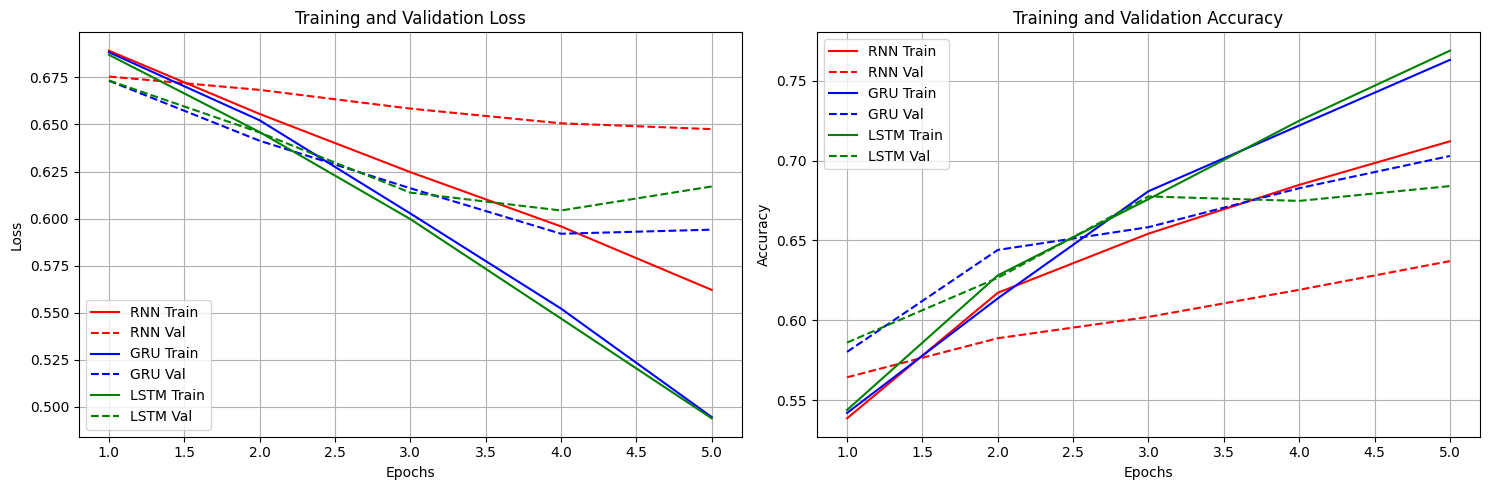

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

colors = {'rnn': 'red', 'gru': 'blue', 'lstm': 'green'}
epochs_range = range(1, N_EPOCHS + 1)

for name in models.keys():
    axs[0].plot(epochs_range, history[name]['train_loss'], color=colors[name], linestyle='-', label=f'{name.upper()} Train')
    axs[0].plot(epochs_range, history[name]['val_loss'], color=colors[name], linestyle='--', label=f'{name.upper()} Val')
axs[0].set_title('Training and Validation Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

for name in models.keys():
    axs[1].plot(epochs_range, history[name]['train_acc'], color=colors[name], linestyle='-', label=f'{name.upper()} Train')
    axs[1].plot(epochs_range, history[name]['val_acc'], color=colors[name], linestyle='--', label=f'{name.upper()} Val')
axs[1].set_title('Training and Validation Accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

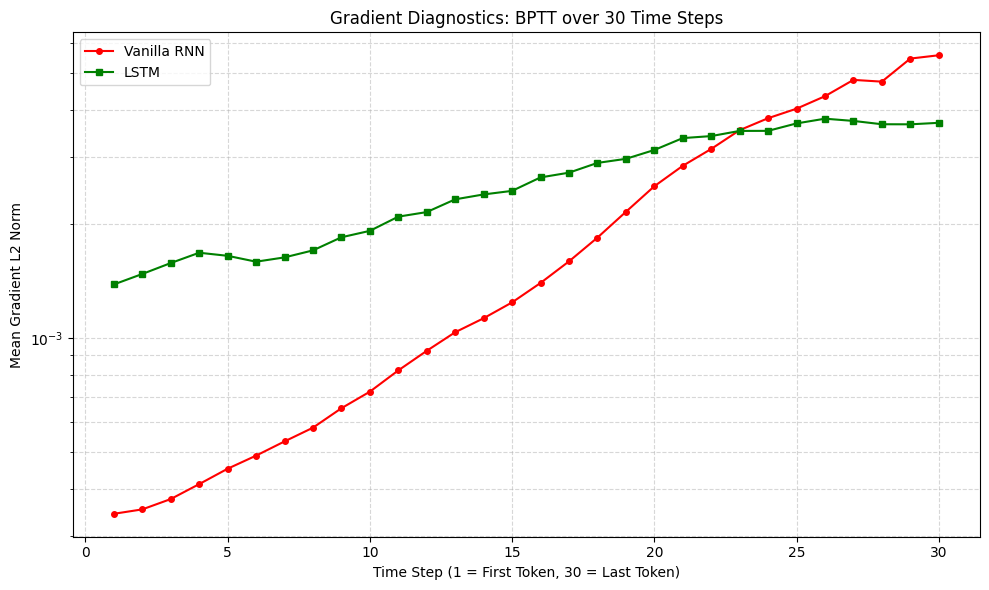


Gradient Ratio (g_1 / g_30):
Vanilla RNN: 6.17e-02
LSTM: 3.75e-01


In [ ]:
def extract_gradients(model, dataset, vocab, rnn_type, device, batch_size=32, seq_len=30):

    model.eval() 
    
    long_samples = []
    for text, label in dataset:
        tokens = tokenize(text)
        if len(tokens) >= seq_len:
            truncated_tokens = tokens[:seq_len]
            encoded = vocab.encode(truncated_tokens)
            long_samples.append((encoded, label))
            if len(long_samples) == batch_size:
                break
                
    if len(long_samples) < batch_size:
        print("Not enough long sentences found!")
        
    texts = torch.tensor([sample[0] for sample in long_samples], dtype=torch.long).to(device)
    labels = torch.tensor([sample[1] for sample in long_samples], dtype=torch.float).to(device)
    

    embedded = model.embedding(texts).clone().detach().requires_grad_(True)
    
    if rnn_type == 'lstm':
        rnn_out, (hidden, cell) = model.rnn(embedded)
    else:
        rnn_out, hidden = model.rnn(embedded)
        
    final_hidden = hidden.squeeze(0)
    
    logits = model.classification_head(final_hidden).squeeze(1)
    
    criterion = nn.BCEWithLogitsLoss()
    loss = criterion(logits, labels)
    loss.backward()
    

    gradients = embedded.grad

    grad_norms = torch.norm(gradients, p=2, dim=2)
    
    mean_grad_norms_over_time = torch.mean(grad_norms, dim=0).cpu().numpy()
    
    return mean_grad_norms_over_time



vanilla_rnn_model = vanilla_rnn_model.to(device)
lstm_model = lstm_model.to(device)

rnn_grads = extract_gradients(vanilla_rnn_model, val_data, vocab, 'rnn', device)

lstm_grads = extract_gradients(lstm_model, val_data, vocab, 'lstm', device)

time_steps = np.arange(1, 31)

plt.figure(figsize=(10, 6))
plt.plot(time_steps, rnn_grads, label='Vanilla RNN', color='red', marker='o', markersize=4)
plt.plot(time_steps, lstm_grads, label='LSTM', color='green', marker='s', markersize=4)

plt.title('Gradient Diagnostics: BPTT over 30 Time Steps')
plt.xlabel('Time Step (1 = First Token, 30 = Last Token)')
plt.ylabel('Mean Gradient L2 Norm')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.savefig('gradient_diagnostics.png')
plt.show()

rnn_ratio = rnn_grads[0] / rnn_grads[-1]
lstm_ratio = lstm_grads[0] / lstm_grads[-1]

print(f"\nGradient Ratio (g_1 / g_30):")
print(f"Vanilla RNN: {rnn_ratio:.2e}")
print(f"LSTM: {lstm_ratio:.2e}")